In [670]:
import geopandas as gpd
import pandas as pd
import os, json, xmltodict
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib
import load_data as ld
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap
%matplotlib inline

In [645]:
shapefile_path = os.path.join(os.getcwd(), "shapefile")

#cwbxml
with open(os.getcwd()+"\\xml\\cwb.xml", encoding="utf-8") as xml_file:
    data_dict = xmltodict.parse(xml_file.read())
    cwb_data = json.loads(json.dumps(data_dict, ensure_ascii=False).encode("utf-8").decode())
    Identifier = cwb_data["earthquake"]["identifier"]
    Schemaver = cwb_data["earthquake"]["schemaVer"]
    Language = cwb_data["earthquake"]["language"]
    Sendername = cwb_data["earthquake"]["senderName"]
    Senttime = cwb_data["earthquake"]["sent"]
    Status = cwb_data["earthquake"]["status"]
    Msgtype = cwb_data["earthquake"]["msgType"]
    MsgNo = cwb_data["earthquake"]["msgNo"]
    Description = cwb_data["earthquake"]["description"]
    Origintime = cwb_data["earthquake"]["originTime"]
    Lat = float(cwb_data["earthquake"]["epicenter"]["epicenterLat"]["#text"])
    Lon = float(cwb_data["earthquake"]["epicenter"]["epicenterLon"]["#text"])
    Depth = cwb_data["earthquake"]["depth"]["#text"]
    Magnitude = cwb_data["earthquake"]["magnitude"]["magnitudeValue"]
    pgaAdj = cwb_data["earthquake"]["pgaAdj"]

    cwb_origin_time = datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00").timestamp()

In [474]:
town = gpd.read_file(shapefile_path+"\TOWN_MOI_1091016.shp", encoding="utf-8")
county = gpd.read_file(shapefile_path+"\COUNTY_MOI_1090820.shp", encoding="utf-8")
crs = county.crs

6.66
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
[18.08]
2021-03-04 22:25:05.703
2021-03-04 22:25:12.363
2021-03-04 22:25:30.438


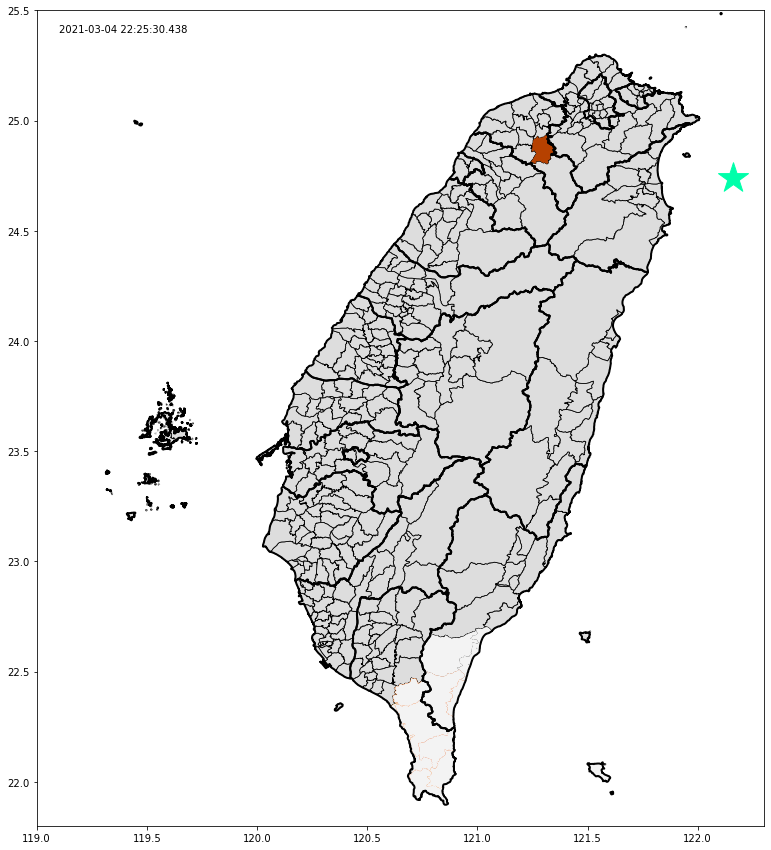

In [680]:
#plotting eq data
color_map = [
        '#f3f3f3',
        '#1aff1a',
        '#ffff00',
        '#ff8900',
        '#ff5500',
        '#b64100',
        '#993300',
        '#aa3c00',
        '#800080'
]
cLevel = [1, 2, 3, 4, 5, 5.5, 6, 6.5, 7]
cmap, norm = matplotlib.colors.from_levels_and_colors(cLevel, color_map, extend="max")

#norm = matplotlib.colors.BoundaryNorm(cLevel,9)
#norm = matplotlib.colors.Normalize(vmin=1, vmax=7, clip=True)
#cm = matplotlib.colors.ListedColormap(color_map)
#cmap1 = LinearSegmentedColormap.from_list("my_colormap", color_map, N=9, gamma=1.0)


#eq_data
data = ld.load_data()
frame_rate = 0.2
p_radius = 0.095
#s_raduis = 
z = 0


#map init
f, axes = plt.subplots(figsize=(15,15))
county.boundary.plot(ax=axes, color="black", edgecolor="black",linewidth=2, zorder=2)
l1 = town.plot(ax=axes, color="#dddddd", edgecolor="black", linewidth=0.8, zorder=1)
    
#set pic location
minx, miny, maxx, maxy = (119, 21.8, 122.3, 25.5)
l1.set_xlim(minx, maxx)
l1.set_ylim(miny, maxy)
current_time = (datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00"))    
axes_time = axes.text(minx+0.1,maxy-0.1,(datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00")))
    
#plotting eq_center
eq_center = pd.DataFrame({"Name":"eq_center", "Latitude":[Lat], "Longitude":[Lon]})
eq_center = gpd.GeoDataFrame(eq_center, geometry=gpd.points_from_xy(eq_center.Longitude, eq_center.Latitude))
eq_center.plot(ax=axes, color="#00ffaa", marker="*", markersize=1000, zorder=3)
op = 0 #temproary

gen_gap_frame(axes, current_time, gap_list, frame_rate, axes.texts, p_radius)

for item in data: 
    
    date = item["date"]
    time = item["time"]
    Areas = item["Areas"]
    AreaDetail = []
    draw_area = gpd.GeoDataFrame()
    print(date,time)
    
    #plotting key frame
    for Area in Areas:
        AreaDetail.append((Area["AreaCode"], Area["Source"], Area["PGA"], float(Area["Intensity"])))
        
    data = pd.DataFrame(AreaDetail, columns=["AreaCode", "Source", "PGA", "Intensity"])
    data = data.sort_values(by=["AreaCode", "PGA"])
    for i in range(len(data)):
        draw = town[town.TOWNCODE == data.loc[i, "AreaCode"]]
        draw = draw.assign(Intensity = data.loc[i, "Intensity"])
        draw_area = draw_area.append(draw)
        
    #p_circle = plt.Circle((Lon, Lat), radius=p_radius, color="red", lw=2.0, fill=False)
    #axes.add_patch(p_circle)
    draw_area.plot("Intensity", ax=axes, cmap=cmap, norm=norm)
    axes.texts[-1].set_text((date+" "+time))
    axes.figure.savefig("s"+str(op)+".png")
    op += 1

    


In [ ]:
t = datetime.now()
ct = date+" "+time
print(t, type(t))
print(ct, type(ct))

ct = datetime.strptime(ct, "%Y-%m-%d %H:%M:%S.%f")

s = t.timestamp() - ct.timestamp()
print(s)
print(round(s,2))

In [662]:
def gen_gap_list(data, cwb_origin_time):
    gap_list = []
    for ind, item in enumerate(data):
        current_datetime = round(datetime.strptime(item["date"]+" "+item["time"], "%Y-%m-%d %H:%M:%S.%f").timestamp(), 2)
        next_ind = ind+1
        
        if ind == 0:
            cwb_gap = round(current_datetime - cwb_origin_time, 2)
            gap_list.append(cwb_gap)

        if next_ind == len(data):
            break
        next_datetime = round(datetime.strptime(data[next_ind]["date"]+" "+data[next_ind]["time"], "%Y-%m-%d %H:%M:%S.%f").timestamp(), 2)

        gap = round(next_datetime - current_datetime, 2)
        gap_list.append(gap)

    return(gap_list)

gap_list = gen_gap_list(ld.load_data(), cwb_origin_time)


In [678]:
def gen_gap_frame(ax, time, gap_list, frame_rate, texts, p_radius):
    #plotting gap frame
    for gaps in gap_list:
        print(gaps)
        for x in range(int(round(gaps/frame_rate))):
            time += timedelta(seconds=frame_rate)
            p_circle = plt.Circle((Lon, Lat), radius=p_radius, color="red", lw=2.0, fill=False)
            ax.add_patch(p_circle)
            p_radius += 0.005
            texts[-1].set_text(time)
            ax.plot()
            ax.figure.savefig(str(x)+".png")
            p_circle.remove()
            print(x)
        gap_list.pop(0)
        print(gap_list)
        break